# Setup and imports

In [1]:
from google.colab import userdata     # Imports secret tokens for logins
from huggingface_hub import login     # Huggingface for fast implementation of transformers
import os
import sys
from pathlib import Path

''' Change snippet and secrets below with your data '''

file_path = ('/content/drive/My Drive/Thesis/belief-repr-1/')
sys.path.append(file_path)
if not os.path.exists('/content/drive/My Drive'):
    from google.colab import drive
    drive.mount('/content/drive')

secrets = {
    'hugging': userdata.get('hugging_token'),
    'wandb': userdata.get('wandb_api'),
    'nnsight': userdata.get('nnsight'),
    'openai': userdata.get('openai_api')
}

HF_TOKEN = secrets['hugging']
login(token=HF_TOKEN)

''' Change snippet and secrets above with your data '''

try:
    import transformer_lens as tlens
    import transformers as trans
    import openai
except:
    #  git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python
    # %pip install wandb -qU
    # %pip install -U bitsandbytes
    # %pip install -U accelerate
    %pip install -U transformers transformer_lens datasets einops jaxtyping
    %pip install openai
    import openai
    import transformer_lens as tlens
    import transformers as trans

"""
try:
    import sae_lens as slens
    from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
    )
    from sae_lens.toolkit.pretrained_saes_directory import get_pretrained_saes_directory
    from sae_vis import SaeVisConfig, SaeVisData, SaeVisLayoutConfig
except:
    # %pip install sae-lens
    #  git+https://github.com/callummcdougall/sae_vis.git@callum/v3
    %pip install openai>=1.56.2 nnsight
    %pip install --upgrade pydantic
    %pip install nnsight
"""

''' Navigate drive '''

import json
import pickle

''' For importing datasets '''

from datasets import load_dataset, Dataset

In [2]:
# import nnsight

# import circuitsvis as cv

''' Tensor manipulation '''

import einops
from einops import einsum
import numpy as np
import torch as t                     # https://pytorch.org/docs/stable/torch.html
import torch.nn as nn                 # https://pytorch.org/docs/stable/nn.html
import torch.nn.functional as F       # https://pytorch.org/docs/stable/nn.functional.html

''' Utils '''

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from rich import print as rprint
from rich.table import Column, Table
from functools import partial         # We need this for fwd_hooks
import copy
from torch.amp import autocast
import gc
import seaborn as sns
import random

''' Should we need strong typing '''

from jaxtyping import Float, Int
from torch import Tensor
from typing import Callable, List, Tuple

''' For visualization of progress (in notebook) and training behavior (in wandb) '''

from tqdm import tqdm
import wandb                          # REMEMBER to log training loops if you want to analyze that behavior | how to: wandb.init() before training, wandb.log() at each epoch, wandb.finish() to clean cache
wandb.login(key=secrets['wandb'])
device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

''' My things '''

from probes import SupervisedProbe, UnsupervisedProbe, probe_sweep
from visualization import *
from utils import *
from data_sets import *
from intervention import *

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alessandro-corona-m (alessandro-corona) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Model and Config

In [3]:
MODEL = 'llama'

def get_llama_legacy():

    tokenizer = trans.LlamaTokenizer.from_pretrained('huggyllama/llama-7b')
    hf_model = trans.LlamaForCausalLM.from_pretrained('huggyllama/llama-7b',
                                                      torch_dtype=t.float16,
                                                      device_map='cpu')
    model = tlens.HookedTransformer.from_pretrained(
        "llama-7b",
        hf_model=hf_model,
        device=t.device('cpu'),
        fold_ln=False,
        center_writing_weights=False,
        center_unembed=False,
        tokenizer=tokenizer
    ).half()

    return model
''' Dictionary for all of the models '''

mymodels = {
    'gemma': lambda: tlens.HookedTransformer.from_pretrained("gemma-2-9b", device=t.device('cpu')).half(),
    'gemma_instruct': lambda: tlens.HookedTransformer.from_pretrained("gemma-2-9b-it", device=t.device('cpu')).half(),
    'gpt': lambda: tlens.HookedTransformer.from_pretrained("gpt2-large", device=device),
    'gpt-j': lambda: tlens.HookedTransformer.from_pretrained("EleutherAI/gpt-j-6B", device=t.device('cpu')).half(),
    'llama_legacy': get_llama_legacy,
    'llama': lambda: tlens.HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B", device=t.device('cpu')).half(),
    'llama_instruct': lambda: tlens.HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct", device=t.device('cpu')).half(),
    'llama_medium': lambda: tlens.HookedTransformer.from_pretrained("Llama-2-13b", device=t.device('cpu')).half(),
    'llama_medium_instruct': lambda: tlens.HookedTransformer.from_pretrained("Llama-2-13b-chat", device=t.device('cpu')).half(),
    'pythia': lambda: tlens.HookedTransformer.from_pretrained("pythia-6.9b-deduped", device=t.device('cpu')).half(),
    'pythia_instruct': lambda: tlens.HookedTransformer.from_pretrained("pythia-6.9b", device=t.device('cpu')).half(),
    'yi': lambda: tlens.HookedTransformer.from_pretrained("yi-6b", device=t.device('cpu')).half(),
    'yi_instruct': lambda: tlens.HookedTransformer.from_pretrained("yi-6b-chat", device=t.device('cpu')).half()
}

model = mymodels[MODEL]()
model.to(device)

# TO DO: add SAE Hooked models

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer
Moving model to device:  cuda


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [4]:
# linear_layer best lr for residual stream on llama == ~1e-2/1e-3
# mlp best lr for residual stream on llama == ~1e-4
# mmp returns immediate results
# no batching is the fastest and works very well for cities.csv
# diminishing return after the 100th epoch for good activations

class ProbeConfig:
    def __init__(self):
        """ General """
        self.device = device
        self.batch_size_extractor = 32
        self.seed = 42
        """ Probe setup """
        self.probe_type = "linear" # Options: linear_layer | linear | mlp | mmp
        self.supervision = "S"
        self.direction_type = None # Options: linear | logistic | mmp | None
        self.verbose = True
        self.with_std = False
        self.var_normalize = True
        self.control = False
        """ Specs """
        self.batch_size = -1
        self.nepochs = 150
        self.ntries = 1
        self.lr = 1e-3
        self.weight_decay = 0.0
        self.dropout = 0.0
        self.C = 1e6
        self.max_iter = 500
        self.test_size = 0.1

probe_config = ProbeConfig()

# Experiments

## Patching

In [21]:
def compute_true_false_ratio(logits):
    """
    Compute the ratio P(True) / P(False) from logits, using multiple token variants.
    """
    true_tokens = ['true', 'True', 'TRUE', 'Ġtrue', 'ĠTrue', 'ĠTRUE']
    false_tokens = ['false', 'False', 'FALSE', 'Ġfalse', 'ĠFalse', 'ĠFALSE']
    true_token_ids = [model.tokenizer.convert_tokens_to_ids(token) for token in true_tokens]
    false_token_ids = [model.tokenizer.convert_tokens_to_ids(token) for token in false_tokens]
    true_token_ids = [tid for tid in true_token_ids if tid != -1]
    false_token_ids = [fid for fid in false_token_ids if fid != -1]

    log_probs = t.nn.functional.log_softmax(logits, dim=-1)[0, -1]
    p_true = t.exp(log_probs[true_token_ids]).sum()
    p_false = t.exp(log_probs[false_token_ids]).sum()

    return t.log(p_true / p_false)

model.reset_hooks()
model.add_hook("hook_embed", lambda tensor, hook: tensor.half())
with t.autocast(device_type='cuda', dtype=t.float16), t.no_grad():
  context = 'The city of Tokyo is in Japan. This statement is: True. \n The city of Hanoi is in Poland. This statement is: False. \n'
  clean_tokens = context + 'The city of Toronto is in Canada. This statement is:'
  corrupted_tokens = context + 'The city of Chicago is in Canada. This statement is:'
  corrupted_tokens = model.to_tokens(corrupted_tokens)
  _, clean_cache = model.run_with_cache(clean_tokens)
  patching_result = tlens.patching.get_act_patch_resid_pre(model=model, corrupted_tokens=corrupted_tokens,
                                      clean_cache=clean_cache, patching_metric=compute_true_false_ratio,
                                      )

  0%|          | 0/1408 [00:00<?, ?it/s]

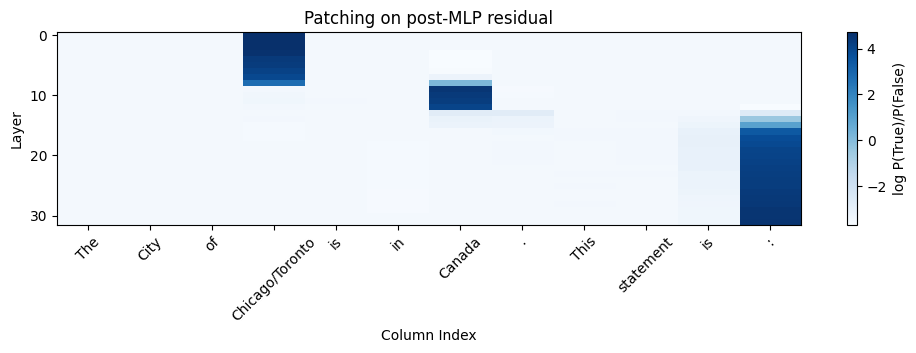

In [22]:
cut = patching_result[:, -12:]
tokz = ['The', 'City', 'of', 'Chicago/Toronto', 'is', 'in', 'Canada', '.', 'This', 'statement', 'is', ':']

plt.figure(figsize=(12,2.5))
plt.imshow(cut.cpu(), cmap='Blues', interpolation='nearest', aspect='auto')
plt.colorbar(label='log P(True)/P(False)')
plt.title('Patching on post-MLP residual')
plt.xticks(ticks=range(len(tokz)), labels=tokz, rotation=45)
plt.xlabel('Column Index')
plt.ylabel('Layer')
plt.show()

## Get Activations

### Supervised

In [93]:
databuilder = TrueFalseEasyBuilder()
dfs, df_all = databuilder.get_dataset()

# Preprocessing

df_all = df_all[df_all['filename'] != 'likely.csv']

# Trim the counterfact_true_false dataset to have balanced classes and a max of 1000 samples per class

target_df = df_all[df_all['filename'] == 'counterfact_true_false.csv']
label_0 = target_df[target_df['label'] == 0]
label_1 = target_df[target_df['label'] == 1]
retain_per_label = 1000
sampled_0 = label_0.sample(n=retain_per_label, random_state=42)
sampled_1 = label_1.sample(n=retain_per_label, random_state=42)
sampled_target_df = pd.concat([sampled_0, sampled_1])
df_all = pd.concat([df_all[df_all['filename'] != 'counterfact_true_false.csv'], sampled_target_df])
df_all['statement'] = df_all['statement'] + ' This sentence is: '

df_train, df_test = train_test_split(
    df_all,
    test_size=0.5,
    stratify=df_all['filename']
)

df_trimmed = df_train.iloc[:-(len(df_train) % probe_config.batch_size_extractor), :]
x = list(df_trimmed['statement'])
y = list(df_trimmed['label'])

Processing files: 100%|██████████| 16/16 [00:00<00:00, 90.49it/s] 


WATCH OUT! Datapoints have different column entries depending on the csv



# Extract & Probe

In [24]:
"""
heads will be a list (layers) of lists (heads) of tensors (head) with shape n_batches d_batch d_head
attn_labels is a tensor of with shape n_batches d_batch
resid_activations will be a dict (activations) of tensors (activation) with shape n_batches d_batch d_model
resid_labels is a tensor of with shape n_batches d_batch
"""

# Heads
attn_activations, attn_labels = extract(model, x, y, device=device, batch_size=probe_config.batch_size_extractor, attn=True)
heads = [decompose_mha(x) for x in attn_activations.values()]

# Residual stream
resid_activations, resid_labels = extract(model, x, y, device=device, batch_size=probe_config.batch_size_extractor, attn=False)

model.to(t.device('cpu'))
gc.collect()
t.cuda.empty_cache()

Moving model to device:  cuda
Moving model to device:  cuda


Processing: 100%|██████████| 286/286 [01:18<00:00,  3.62it/s]


Moving model to device:  cpu
Moving model to device:  cuda
Moving model to device:  cuda


Processing: 100%|██████████| 286/286 [01:30<00:00,  3.17it/s]


Moving model to device:  cpu
Moving model to device:  cpu


## Playing with KDE

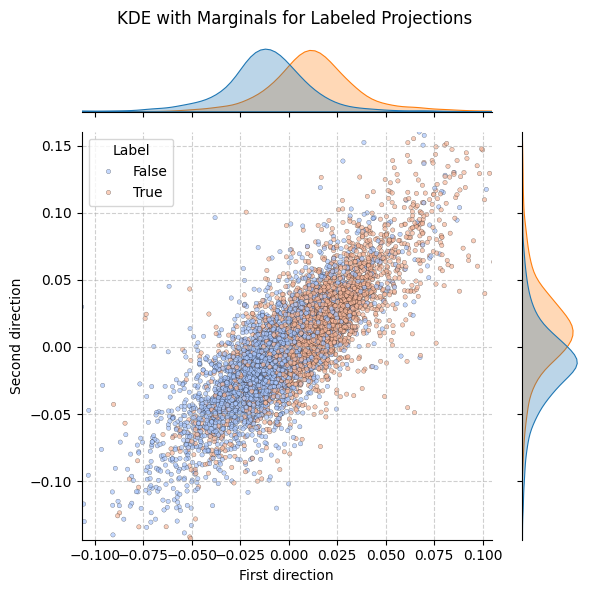

In [29]:
from sklearn.linear_model import LogisticRegression

data = heads[15][2]                             # One of the good heads from llama
labels = 1 - attn_labels

probe = LogisticRegression(max_iter=probe_config.max_iter,
                                            solver="lbfgs",
                                            C=probe_config.C,
                                            random_state=probe_config.seed,
                                            n_jobs=-1)

kde(data=data, labels=labels, model=probe,
    n_dir=2, zoom_strength=0.5, adjust=0.01,    # Adjust according for the required viz
    kernel=False, scatter=True, pca=False)

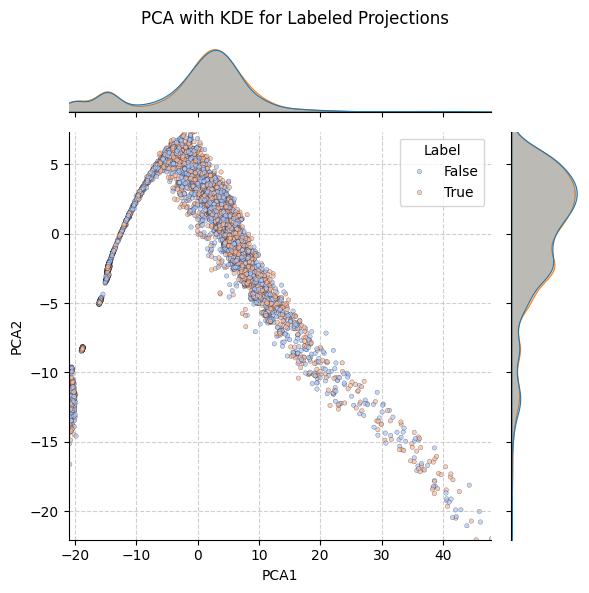

In [33]:
# Plot PCA'd data for the same head

kde(data=data, labels=labels, model=probe,
    n_dir=2, zoom_strength=0.0, adjust=1,
    kernel=False, scatter=True, pca=True)

## Probe Sweeps (This part may take several minutes depending on resources)

### Heads

In [35]:
probe_config.var_normalize = False
probe_config.verbose = False
tot_accuracies_heads = []
tot_directions_heads = []
tot_probes_heads = []

for layer in tqdm(range(len(heads)), desc="Layers"):
  accuracies, directions, probes = probe_sweep(heads[layer], attn_labels, probe_config)
  tot_accuracies_heads.append(accuracies)
  tot_directions_heads.append(directions)
  tot_probes_heads.append(probes)

tot_accuracies_heads = np.array(tot_accuracies_heads)

top_heads, top_values = get_top_heads(tot_accuracies_heads, 5)
print(top_heads, top_values)

Layers: 100%|██████████| 32/32 [21:02<00:00, 39.47s/it]

[[14 27]
 [16 28]
 [15 18]
 [16 31]
 [12 14]] [0.8569869  0.84497817 0.84497817 0.84388646 0.84279476]


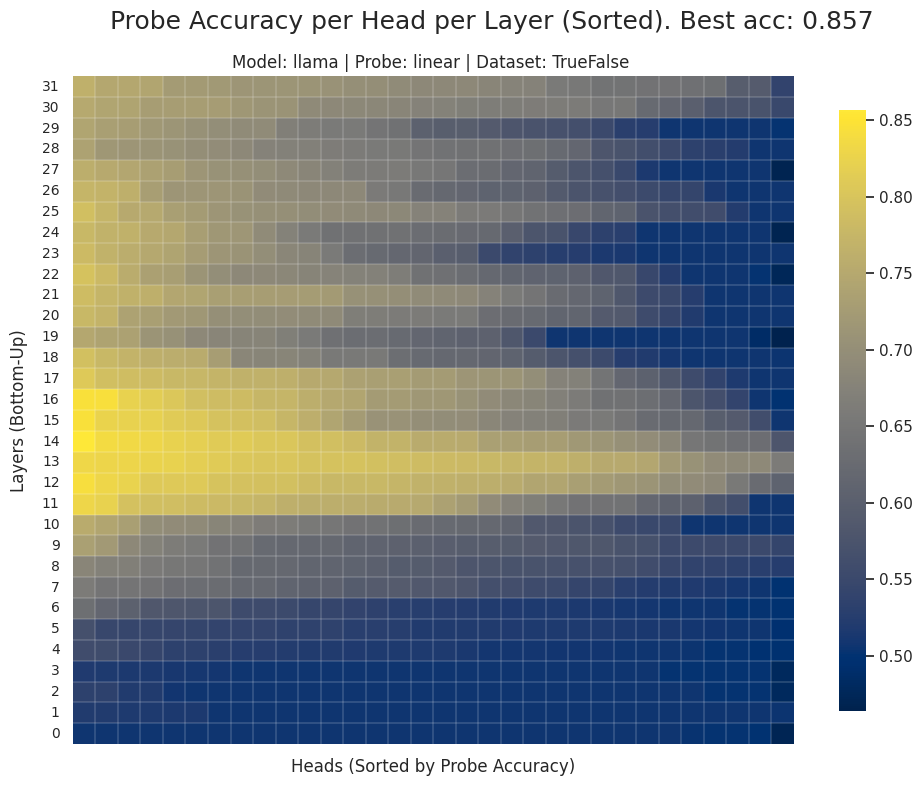

In [36]:
pretty_heatmap(tot_accuracies_heads,
               title=f"Probe Accuracy per Head per Layer (Sorted). Best acc: {top_values[0]:.3f}",
               x_axis="Heads (Sorted by Probe Accuracy)",
               y_axis="Layers (Bottom-Up)",
               model=f'{MODEL}',
               probe=probe_config.probe_type,
               dataset="TrueFalse")

### Residual

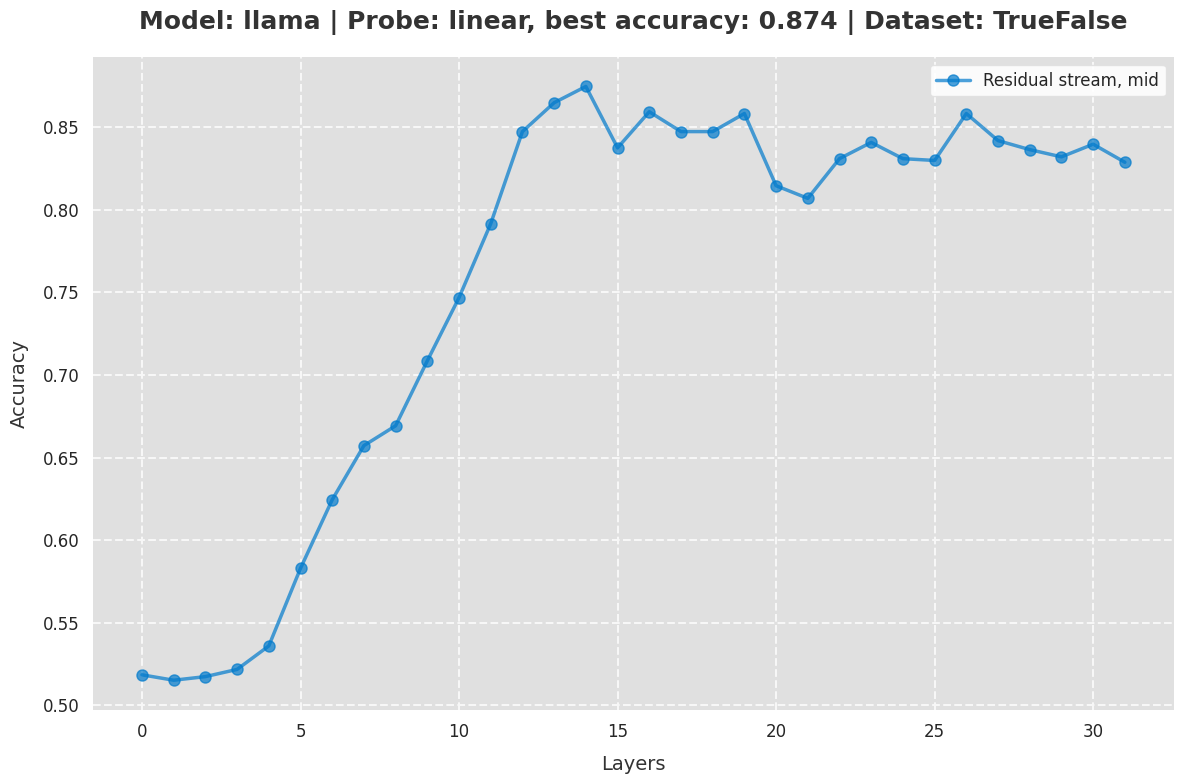

In [37]:
# I didn't tqdm wrap the loop, the cell takes ~ the time of the sweep on attn heads

accuracies, directions, _ = probe_sweep(resid_activations.values(), resid_labels, probe_config)

pretty_line(x=accuracies,
            title=f"Model: {MODEL} | Probe: {probe_config.probe_type}, best accuracy: {np.array(accuracies).max():.3f} | Dataset: TrueFalse",
            x_axis="Layers",
            y_axis="Accuracy",
            x_label="Residual stream, mid",
            y_label="Accuracy")

# Intervene

In [110]:
probe_config.direction_type = 'mmp'

# attn

with open(f'{file_path}/thetas/{MODEL}_direction_{probe_config.direction_type}.pkl', 'rb') as file:
    directions = pickle.load(file)
with open(f'{file_path}/thetas/{MODEL}_accuracies_{probe_config.direction_type}.pkl', 'rb') as file:
    accuracies = pickle.load(file)

directions = t.stack([t.stack(sublist, dim=0) for sublist in directions], dim=0)

In [111]:
# resid

with open(f'{file_path}/thetas/{MODEL}_line_accuracies_{probe_config.direction_type}.pkl', 'rb') as file:
    accuracies = pickle.load(file)
with open(f'{file_path}/thetas/{MODEL}_line_directions_{probe_config.direction_type}.pkl', 'rb') as file:
    directions = pickle.load(file)

random_directions = [t.rand_like(x, dtype=t.float) * 0.2 - 0.1 for x in directions]

In [112]:
df_for_int = df_test.copy()
df_for_int['statement'] = df_test['statement'].str[:-1]
df_true = df_for_int[df_for_int['label'] == 1]
df_false = df_for_int[df_for_int['label'] == 0]
df_to_test = df_true # Use df_true for True -> False and df_false for False -> True


In [113]:
test_sentences = list(df_to_test['statement'])
test_sample = random.sample(
                            test_sentences,
                            # len(test_sentences)              # Actual test, full dataset
                            50                                 # For sweeping purposes
                            )
sampled_df = df_to_test[df_to_test['statement'].isin(test_sample)]
prompts = list(sampled_df['statement'])
labels = list(sampled_df['label'])

In [114]:
''' == PARAMETER SWEEP == '''

best_k = 7
best_a = -4

# strength = np.abs(best_k*best_a/(model.cfg.n_heads*model.cfg.n_layers))
strength = np.abs(best_k*best_a/model.cfg.n_layers) # Resid
print("Intervention Strength: ", strength)

with autocast('cuda'):
  metric = 'boolprobs'

  ''' Find params through sweeping '''
  ks = [8, 9, 10, 11, 12]
  alphas = [-4, -5, -6, -7, -8] if labels[0] == 1 else [0, 2, 3, 4, 5]     # We steer towards false if we have the true dataset and vice versa
  ''' Once you have found the best params, use them below with the full dataset'''
  # ks = [best_k]
  # alphas = [0, best_a]                                                  # We keep alpha=0 to see the original accuracy

  for_sweep = parameter_sweep(
      model,
      prompts,
      accuracies,
      directions,
      ks=ks,
      alphas=alphas,
      metric=metric,
      secret=secrets['openai'],
      labels=labels,
      attn=False
  )

Intervention Strength:  0.875


0it [00:00, ?it/s]

Steering top 8 activations



0it [00:00, ?it/s]

0it [00:00, ?it/s]

With strength -4


...


3it [00:10,  3.60s/it]

4it [01:22, 17.96s/it]

With strength -7



4it [00:14,  3.63s/it]

4it [01:26, 17.96s/it]

With strength -8



5it [00:18,  3.62s/it]
5it [01:29, 17.99s/it]


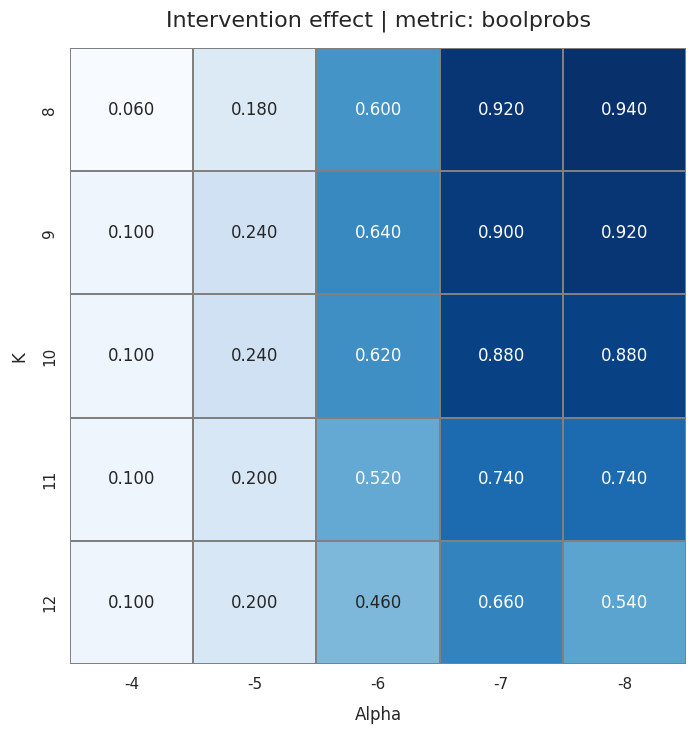

In [117]:
boolp, probdiff = for_sweep

pretty_sweep(
             boolp,              # or boolp
             ks=ks,
             alphas=alphas,
             metric=metric
             )